In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("dark")
from sklearn.impute import KNNImputer

In [2]:
df_original = pd.read_csv(r"C:\Users\RamziAbdelhafidh\DocumentsData Science\Designing-an-App-for-Public-Health\data\en.openfoodfacts.org.products.csv", sep='\t')

C:\Users\RamziAbdelhafidh\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3071: DtypeWarning: Columns (0,12,26,27,28,30,51,63) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


# Dataset Pre-exploration

In [3]:
df_original.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,carbon-footprint-from-meat-or-fish_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g
0,0000000000017,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1529059080,2018-06-15T10:38:00Z,1561463718,2019-06-25T11:55:18Z,Vitória crackers,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000000000031,http://world-en.openfoodfacts.org/product/0000...,isagoofy,1539464774,2018-10-13T21:06:14Z,1539464817,2018-10-13T21:06:57Z,Cacao,NaN,130 g,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000000000003327986,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1574175736,2019-11-19T15:02:16Z,1574175737,2019-11-19T15:02:17Z,Filetes de pollo empanado,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0000000000100,http://world-en.openfoodfacts.org/product/0000...,del51,1444572561,2015-10-11T14:09:21Z,1444659212,2015-10-12T14:13:32Z,moutarde au moût de raisin,NaN,100g,...,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00000000001111111111,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1560020173,2019-06-08T18:56:13Z,1560020173,2019-06-08T18:56:13Z,Sfiudwx,NaN,dgesc,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1524579 entries, 0 to 1524578
Columns: 183 entries, code to carnitine_100g
dtypes: float64(123), int64(2), object(58)
memory usage: 2.1+ GB


In [5]:
df_original.describe()

,created_t,last_modified_t,cities,allergens_en,serving_quantity,no_nutriments,additives_n,additives,ingredients_from_palm_oil_n,ingredients_from_palm_oil,...,carbon-footprint-from-meat-or-fish_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g
count,1.524579e+06,1.524579e+06,0.0,0.0,4.472190e+05,0.0,655785.000000,0.0,655785.000000,0.0,...,11026.000000,609885.000000,25.000000,3.000000,0.0,39.000000,1712.000000,25.000000,44.000000,20.000000
mean,1.541742e+09,1.576448e+09,NaN,NaN,2.484490e+16,NaN,2.051166,NaN,0.020772,NaN,...,628.854565,9.148105,8.160000,29.333333,NaN,0.066459,0.068920,3.590800,0.026056,0.038885
std,4.694753e+07,2.675049e+07,NaN,NaN,1.661489e+19,NaN,2.923523,NaN,0.144427,NaN,...,6307.248215,8.907434,9.463438,15.011107,NaN,0.037367,1.826776,1.630424,0.026745,0.125679
min,1.328021e+09,1.333873e+09,NaN,NaN,0.000000e+00,NaN,0.000000,NaN,0.000000,NaN,...,0.049000,-15.000000,-6.000000,14.000000,NaN,0.000000,0.000000,0.400000,0.001350,0.004000
25%,1.512328e+09,1.566592e+09,NaN,NaN,2.800000e+01,NaN,0.000000,NaN,0.000000,NaN,...,111.000000,1.000000,0.000000,22.000000,NaN,0.047500,0.000008,2.800000,0.009850,0.007000
50%,1.551208e+09,1.586693e+09,NaN,NaN,5.000000e+01,NaN,1.000000,NaN,0.000000,NaN,...,333.000000,10.000000,5.000000,30.000000,NaN,0.069000,0.000023,3.900000,0.021000,0.008500
75%,1.581550e+09,1.591160e+09,NaN,NaN,1.130000e+02,NaN,3.000000,NaN,0.000000,NaN,...,614.200000,16.000000,17.000000,37.000000,NaN,0.089000,0.000095,4.400000,0.027700,0.011250
max,1.605696e+09,1.605696e+09,NaN,NaN,1.111111e+22,NaN,49.000000,NaN,3.000000,NaN,...,656298.600000,40.000000,25.000000,44.000000,NaN,0.150000,54.000000,7.300000,0.150000,0.572000


# Removing columns with too many missing values

In [6]:
initial_columns = list(df_original.columns)
retained_columns = []
retained_columns_percentages = {}

for column in initial_columns:
    # Calculate percentage of missing values
    N_missing_data = df_original[column].isnull().sum()
    N_total_data = df_original[column].size
    percentage = N_missing_data / N_total_data
    
    # Keep columns with missing value percentage below threshold
    threshold = 0.7
    if percentage < threshold:
        retained_columns.append(column)
        retained_columns_percentages[column] = percentage

# Redefine the dataframe
df_clean_columns = df_original[retained_columns] 

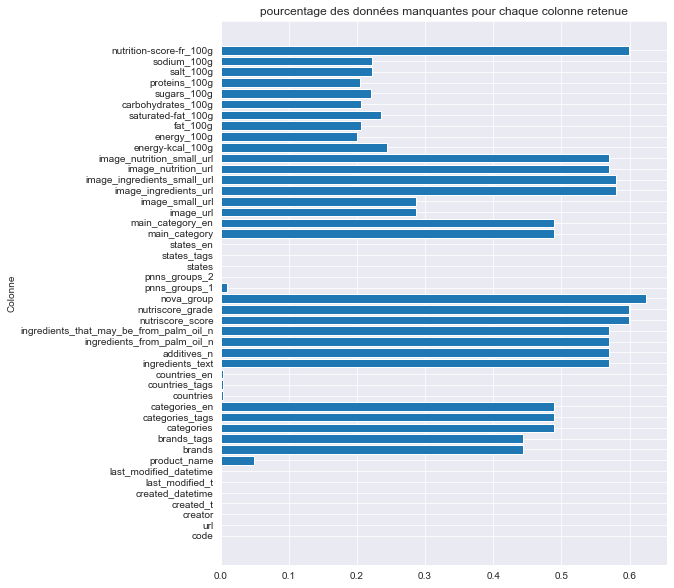

In [7]:
# Visualization of missing data percentages for each retained column
plt.figure(figsize=(8, 10))
plt.barh(range(len(retained_columns_percentages)), list(retained_columns_percentages.values()))
plt.yticks(range(len(retained_columns_percentages)), list(retained_columns_percentages.keys()))
plt.grid()
plt.title("Missing Data Percentage for Each Retained Column")
plt.xlabel("Missing Value Percentage")
plt.ylabel("Column")
plt.show()

# Elimination des colonnes qui ne sont pas intéressantes

In [8]:
# définir la liste des colonnes à éliminer
columns_to_drop = [ 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t',\
                   'product_name', 'brands', 'brands_tags', 'categories', 'categories_tags',\
                   'categories_en', 'nova_group', 'states', 'states_tags', 'states_en',\
                   'main_category', 'main_category_en', 'image_url', 'image_small_url',\
                   'image_ingredients_url', 'image_ingredients_small_url', 'image_nutrition_url',\
                   'image_nutrition_small_url', 'energy-kcal_100g']
# éliminer la liste précedente de la dataframe
df_clean_columns = df_clean_columns.drop(columns_to_drop, axis = 1) 


# Elimination des lignes avec trop de valeurs manquantes

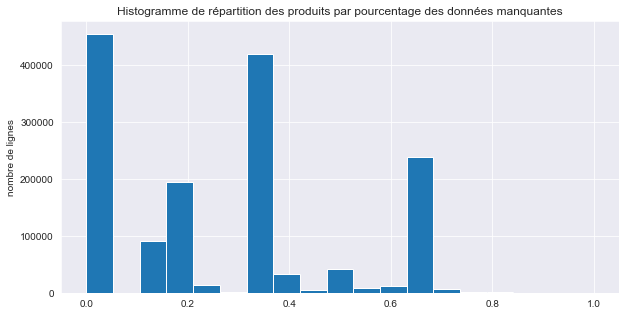

In [9]:
# calculer le pourcentage des données manquantes pour chaque ligne (pour chaque produit)
percentages = df_clean_columns.isna().sum(axis = 1) / df_clean_columns.shape[1]
# Afficher l'histogramme des pourcentages
plt.figure(figsize=(10, 5))
plt.grid()
plt.hist(x=percentages, bins=np.linspace(0, 1, 20))
plt.title("Histogramme de répartition des produits par pourcentage des données manquantes")
plt.xlabel = ("pourcentage des données manquantes")
plt.ylabel("nombre de lignes")
plt.show()

In [10]:
# définir un seuil maximal de pourcentage de données manquantes
upper_threshold = 0.8
# Définir la nouvelle dataframe qui comprend que les lignes qui ne dépassent pas le seuil
df_clean_columns_rows = df_clean_columns[percentages < upper_threshold].copy()

print("le nombre de lignes éliminées est égal à "+str(df_clean_columns.shape[0]-df_clean_columns_rows.shape[0]))

n_rows_missing_data = df_clean_columns_rows.shape[0]

le nombre de lignes éliminées est égal à 2157


# Elimination des produits dupliqués

In [11]:
initial_n_rows = df_clean_columns_rows.shape[0]
df_clean_columns_rows = df_clean_columns_rows.drop_duplicates(subset='code', keep='first')
final_n_rows = df_clean_columns_rows.shape[0]
print("Le nombre de lignes éliminés est égal à "+str(initial_n_rows-final_n_rows))

Le nombre de lignes éliminés est égal à 369


# Elimination des valeurs aberrantes au sens métier

In [12]:
df_before_outliers_treatement = df_clean_columns_rows.copy()

In [13]:
# energy_100g doit toujors être inférieur à 3700 kj
energy_100g_filter = (df_before_outliers_treatement['energy_100g'] >= 0)&(df_before_outliers_treatement['energy_100g'] <= 3700)
df_after_first_outliers_treatement = df_before_outliers_treatement[energy_100g_filter]

In [14]:
# nutrition_score_fr_100g doit être supérieur à -10
nutrition_score_filter = (40 >= df_after_first_outliers_treatement['nutrition-score-fr_100g']) & (df_after_first_outliers_treatement['nutrition-score-fr_100g']>= -15)
df_after_first_outliers_treatement = df_after_first_outliers_treatement[nutrition_score_filter]

In [15]:
# le poids par 100g de certains composants doit être inférieur ou égal à 100g
nutriments_to_test = ['sodium_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', \
                      'sugars_100g', 'proteins_100g', 'salt_100g']
for nutriment in nutriments_to_test:
    filter_ = (0 <= df_after_first_outliers_treatement[nutriment]) & (df_after_first_outliers_treatement[nutriment]<= 100)
    df_after_first_outliers_treatement = df_after_first_outliers_treatement[filter_]

# Elimination des valeurs aberrantes au sens statistique

In [16]:
df_after_first_outliers_treatement.dtypes

code                                        object
last_modified_datetime                      object
countries                                   object
countries_tags                              object
countries_en                                object
ingredients_text                            object
additives_n                                float64
ingredients_from_palm_oil_n                float64
ingredients_that_may_be_from_palm_oil_n    float64
nutriscore_score                           float64
nutriscore_grade                            object
pnns_groups_1                               object
pnns_groups_2                               object
energy_100g                                float64
fat_100g                                   float64
saturated-fat_100g                         float64
carbohydrates_100g                         float64
sugars_100g                                float64
proteins_100g                              float64
salt_100g                      

In [17]:
df_after_second_outliers_treatement = df_after_first_outliers_treatement.copy()

# définir une liste des colonnes avec des valeurs numériques
numeric_columns = list(df_after_first_outliers_treatement.select_dtypes(include=float).columns)

# éliminer les valeurs qui sont à une distance supérieure de 3 std de la moyenne
for column in numeric_columns:
    df = df_after_second_outliers_treatement[column]
    mean = df.mean()
    std = df.std()
    filter_ = np.abs(df-mean) <= 3*std
    df_after_second_outliers_treatement = df_after_second_outliers_treatement[filter_]

# Visualiser les box plot des variables numériques

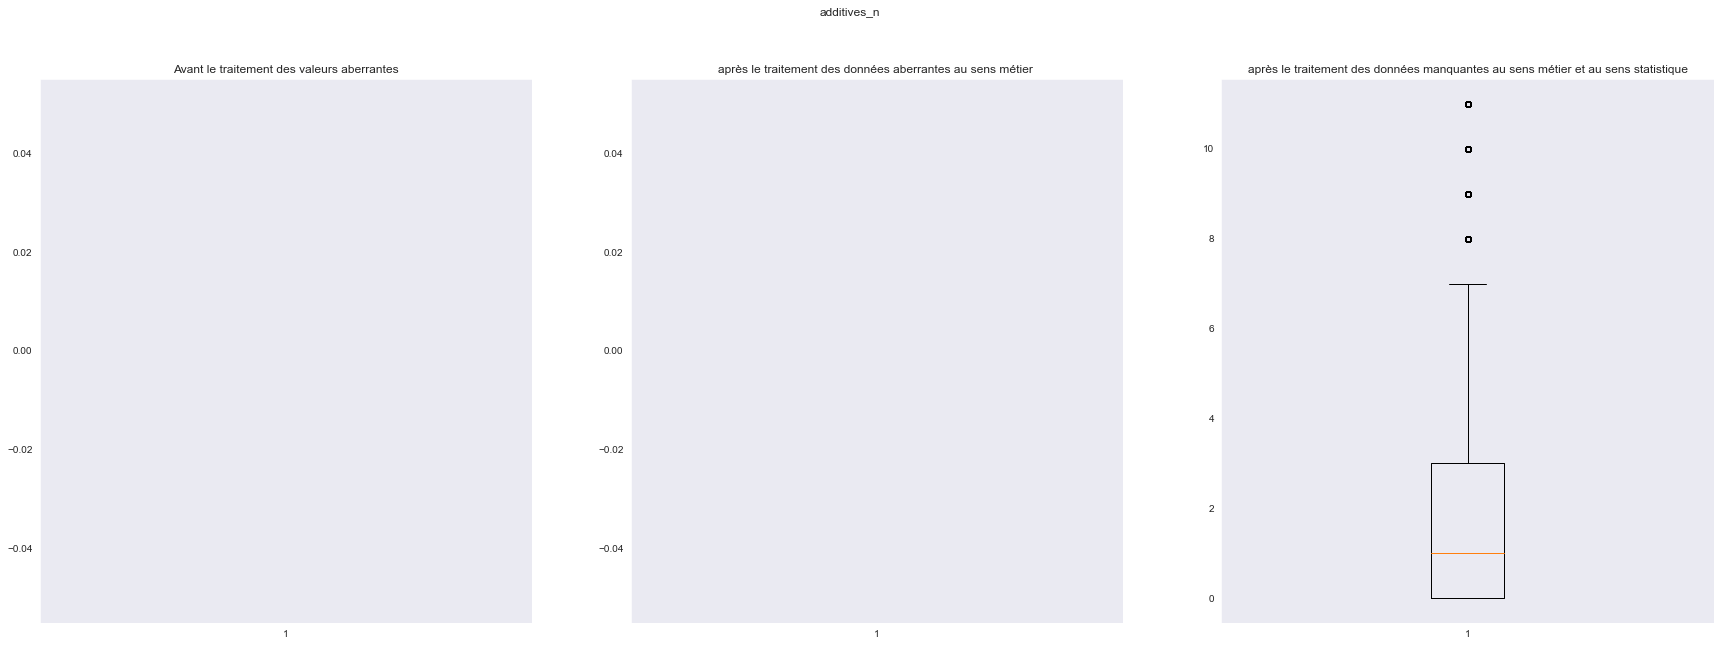

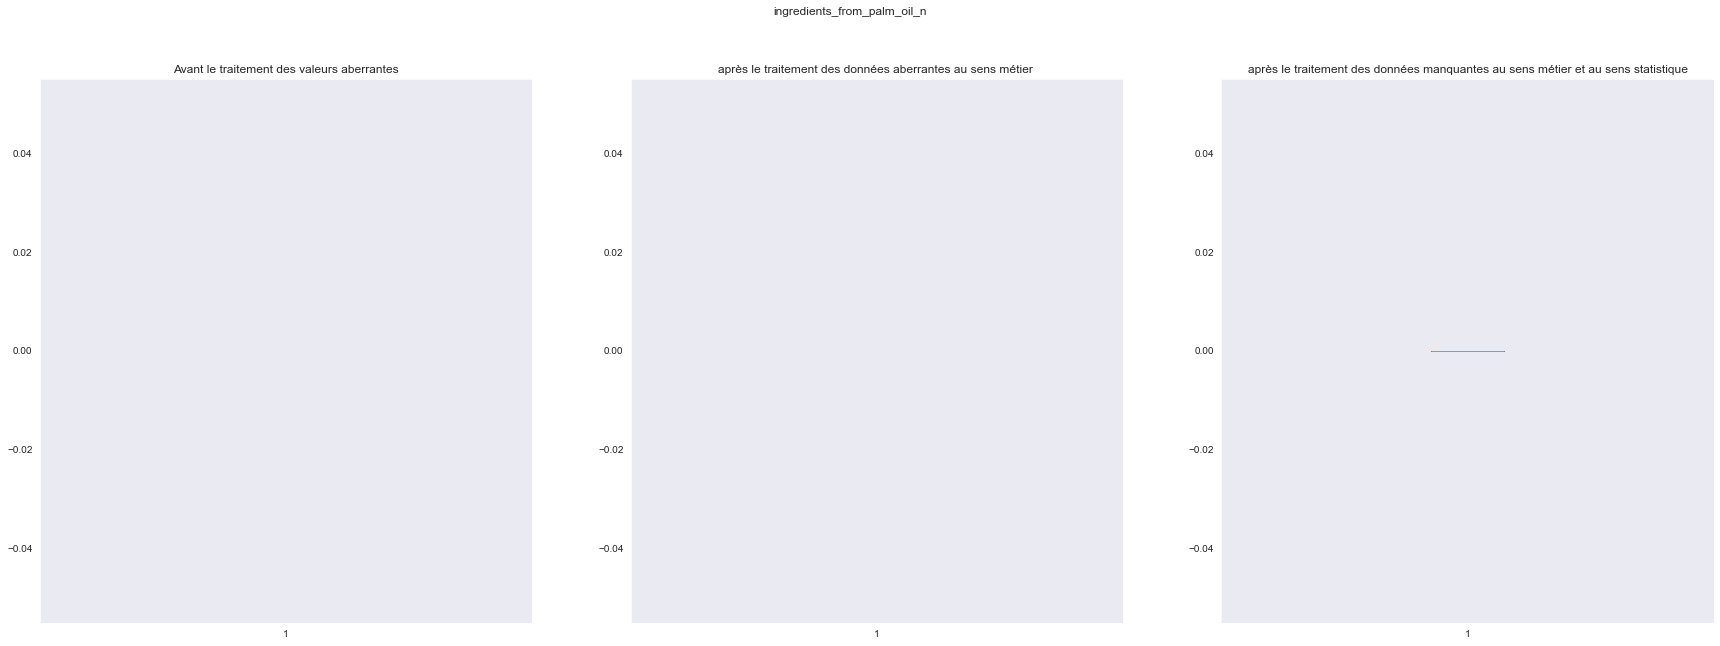

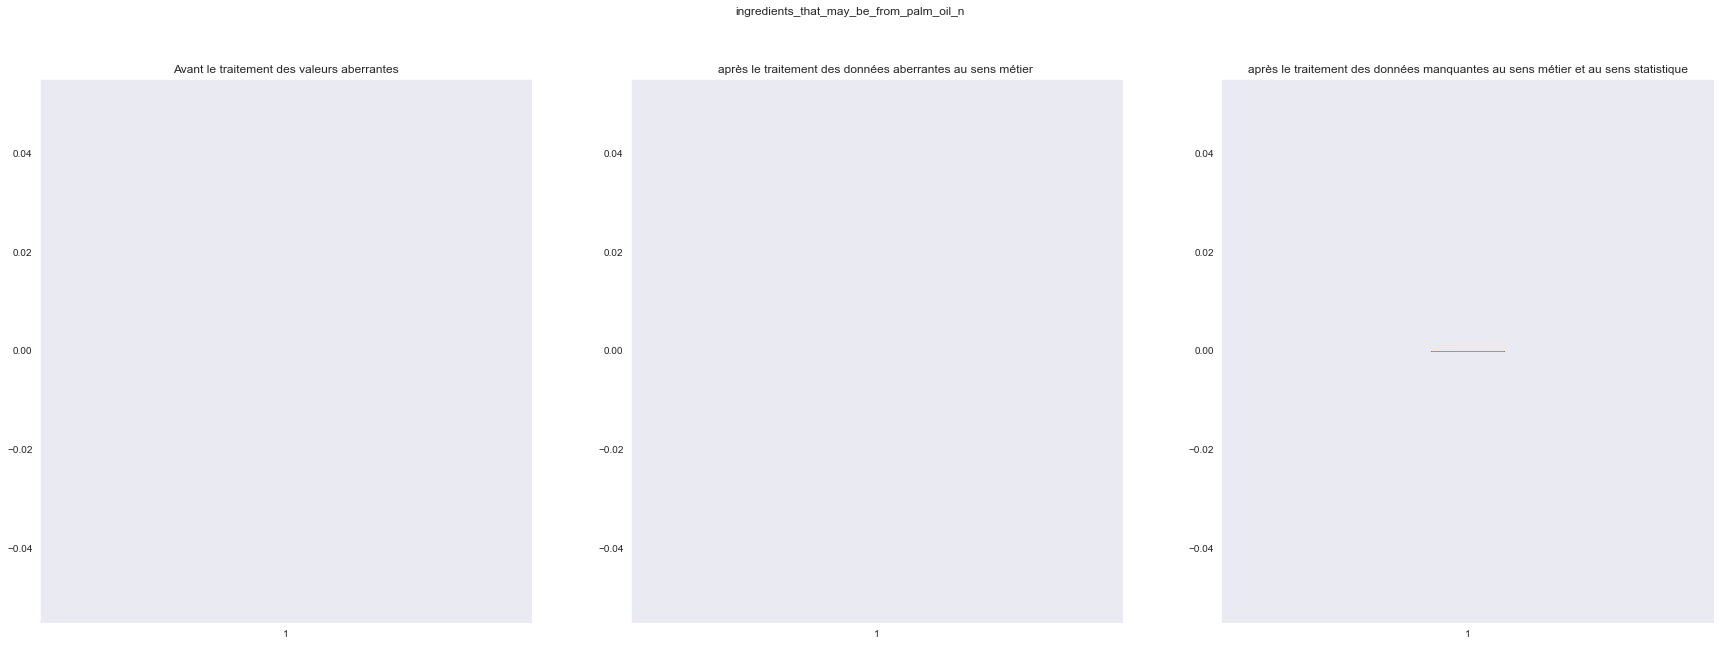

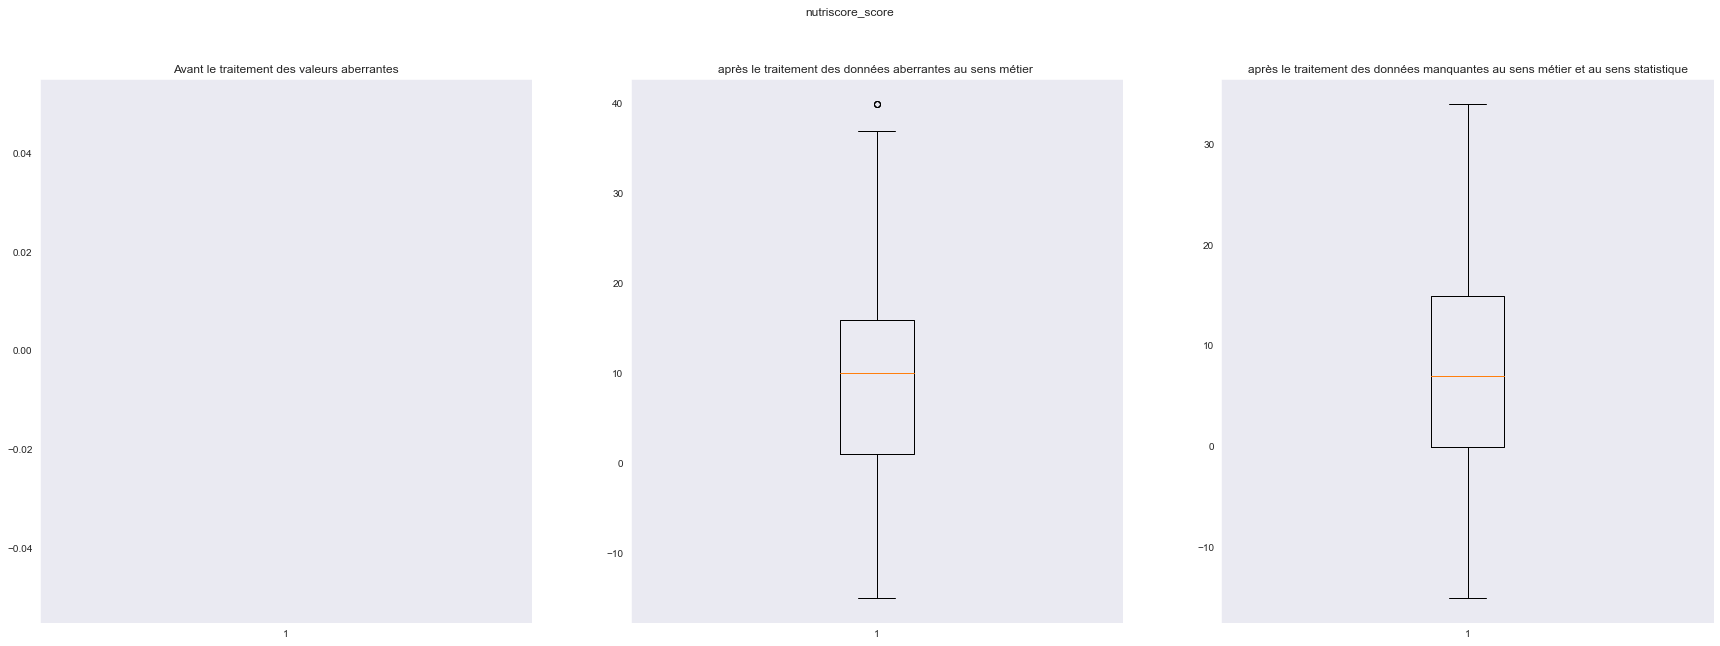

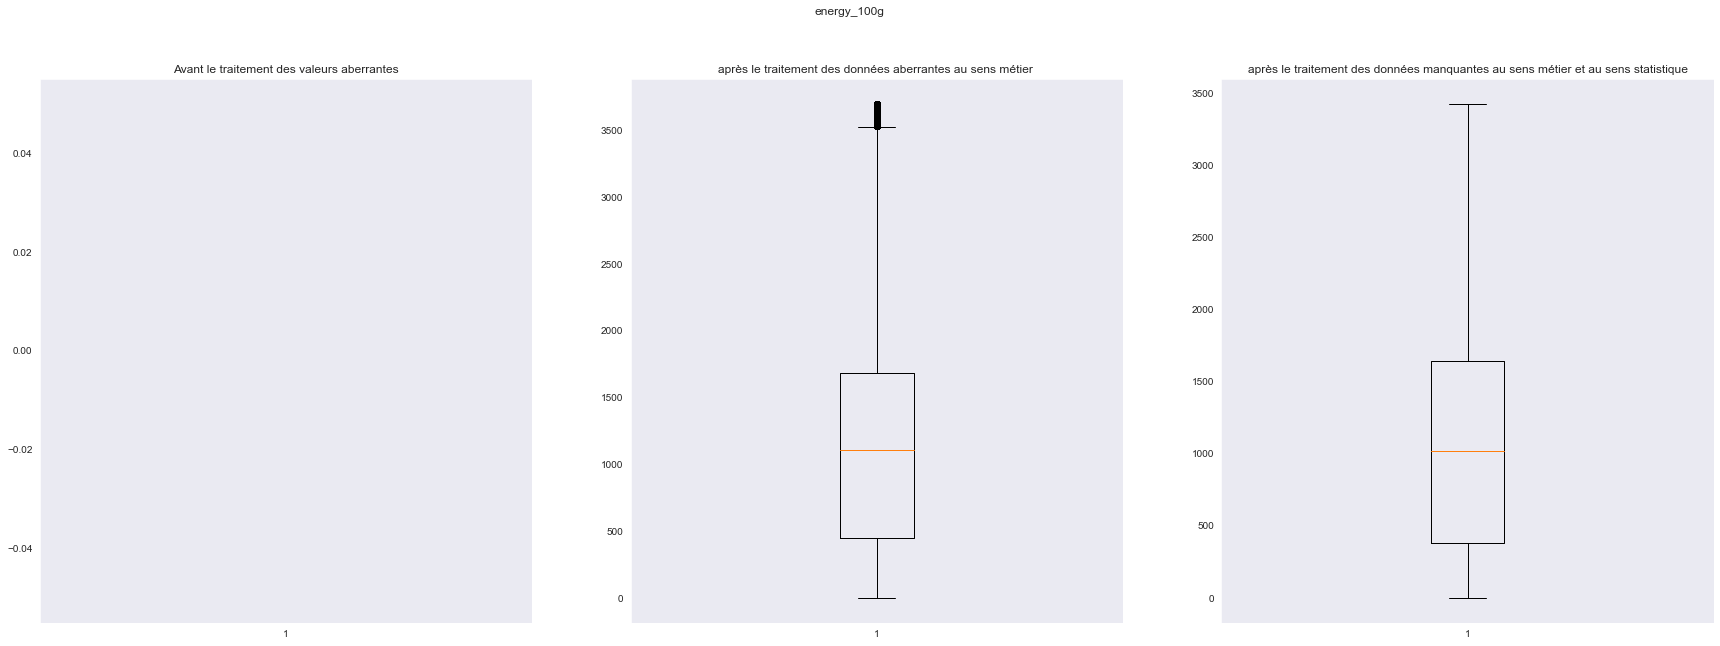

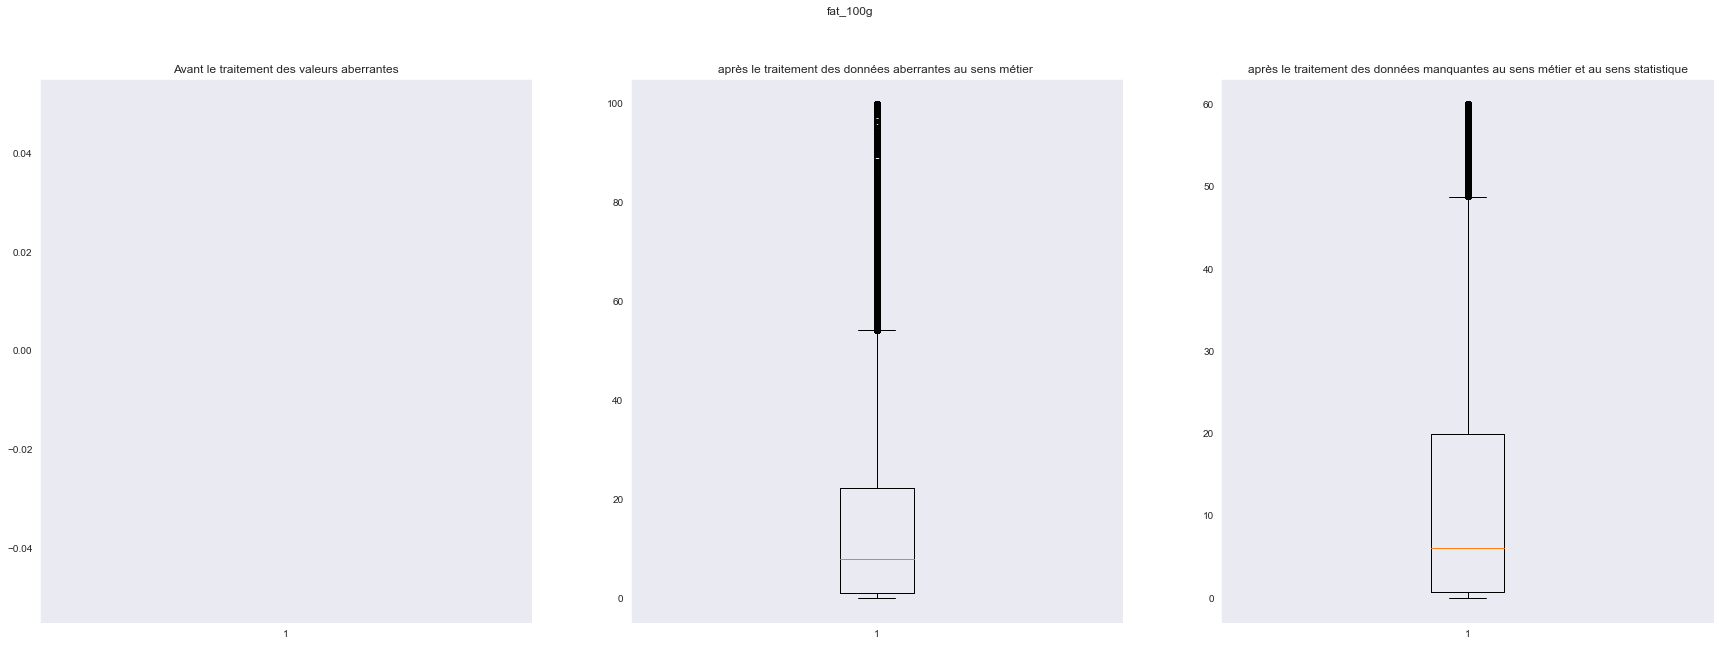

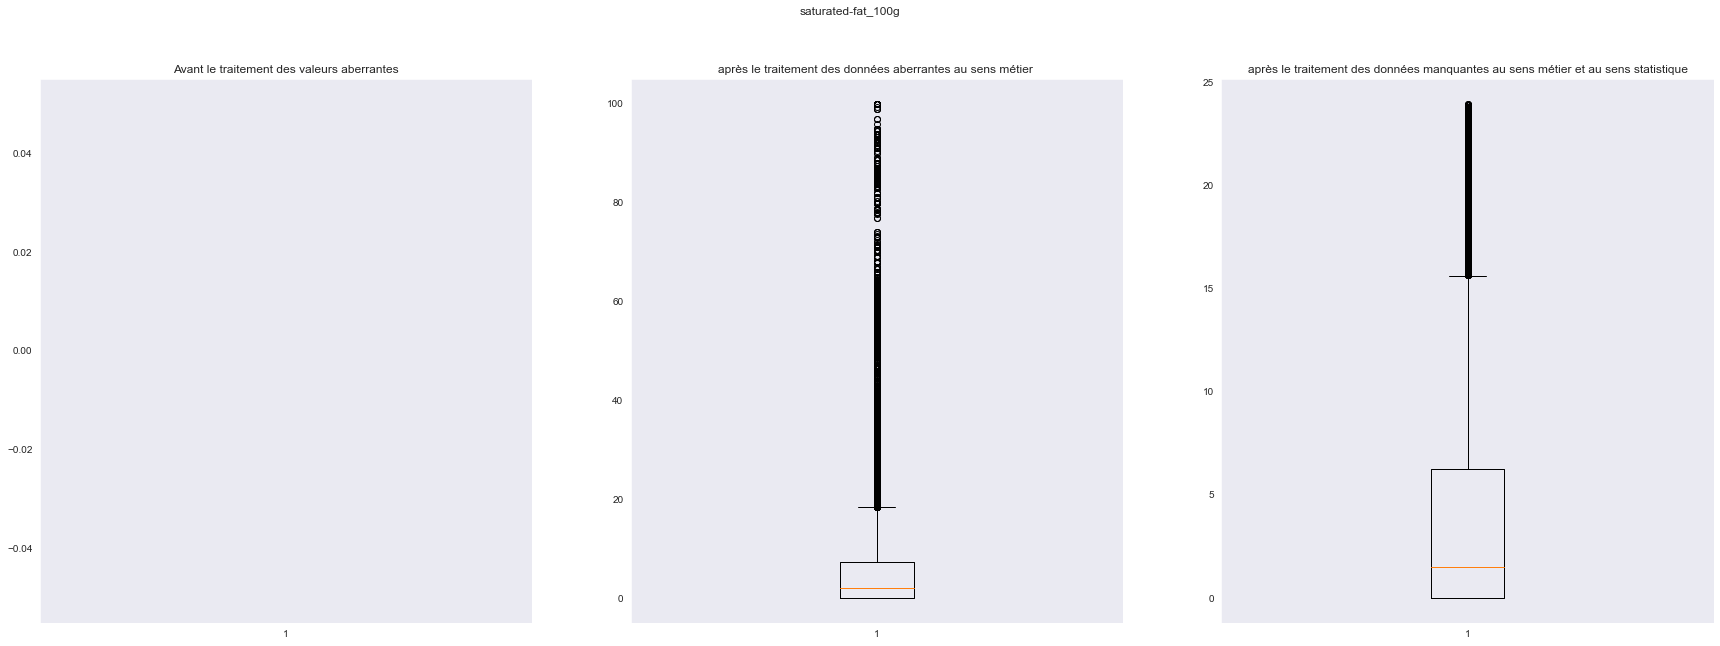

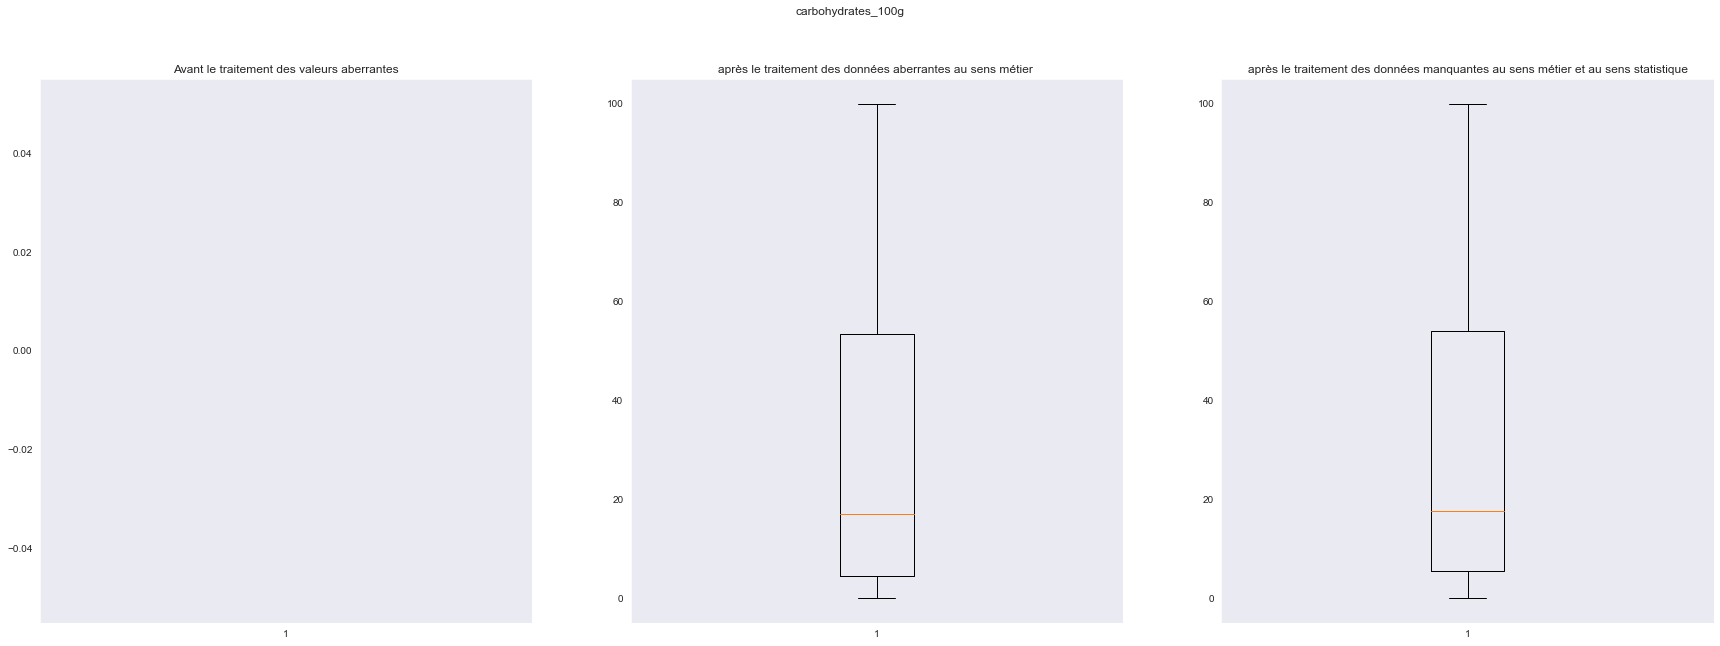

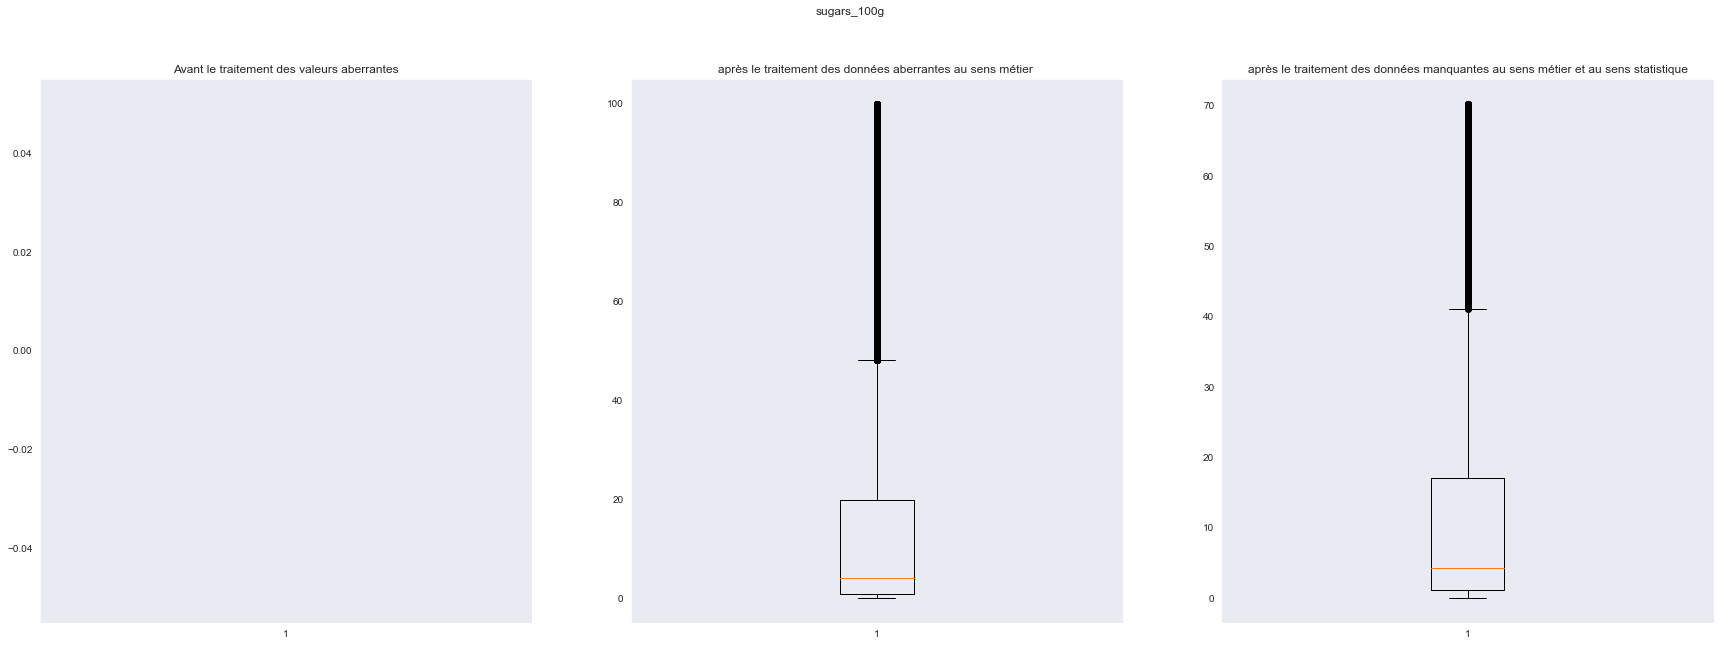

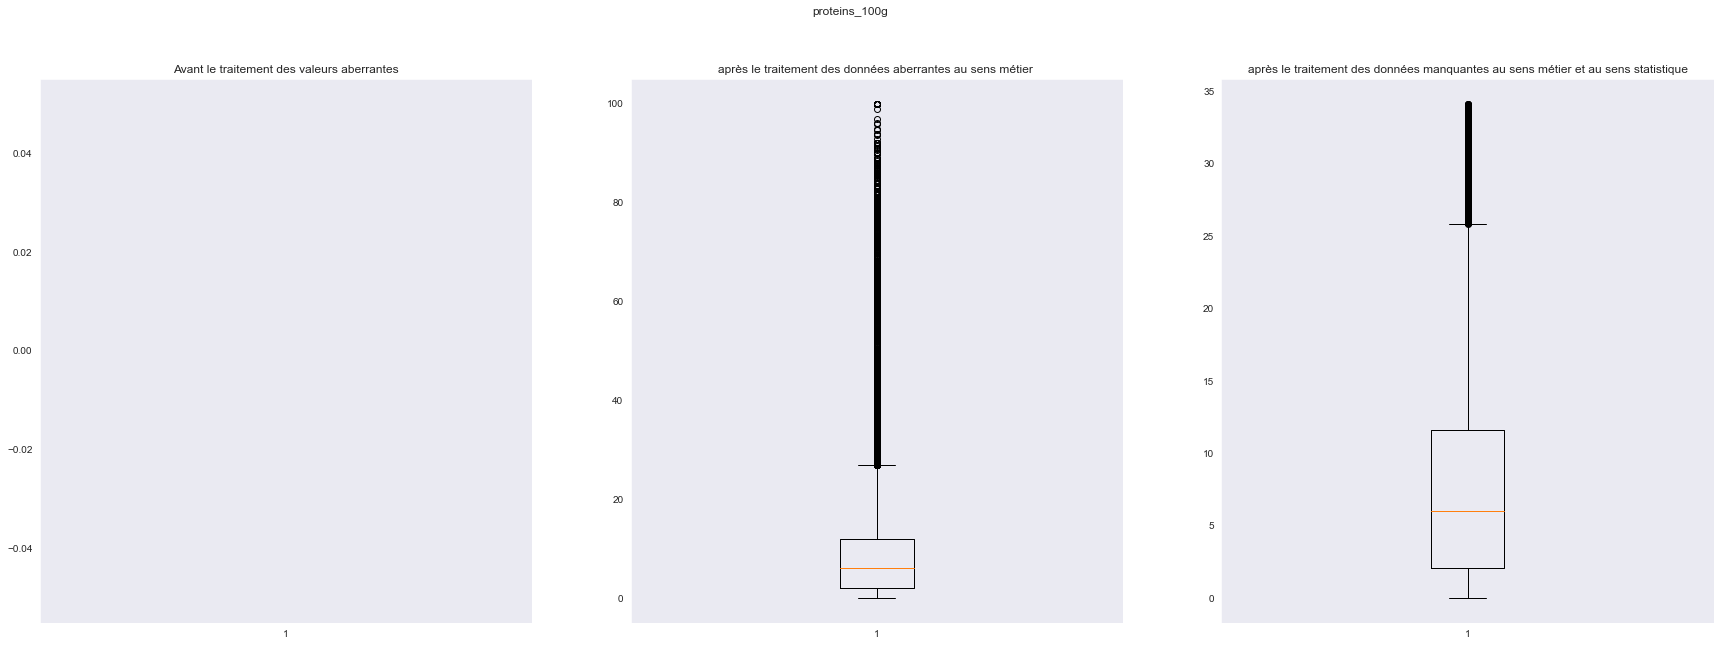

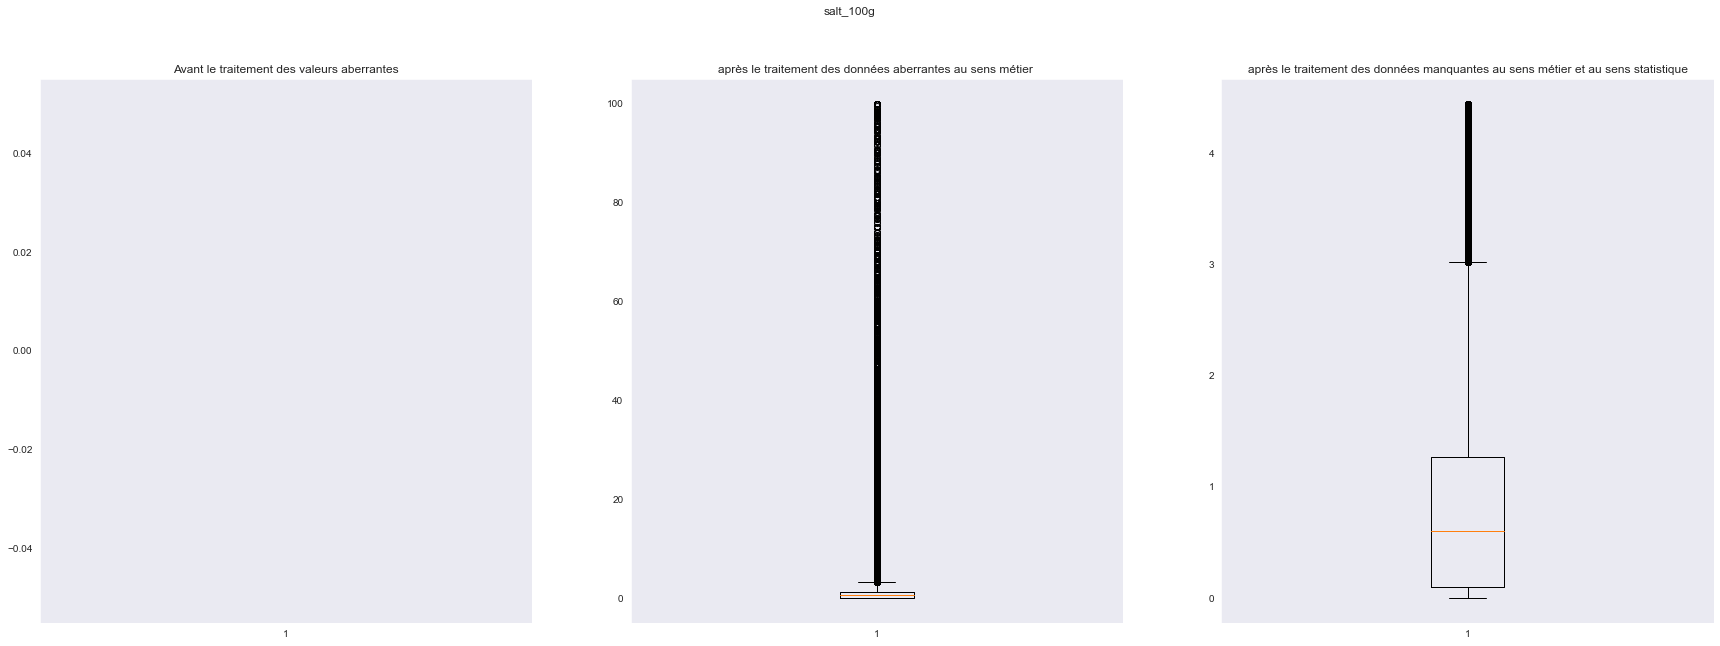

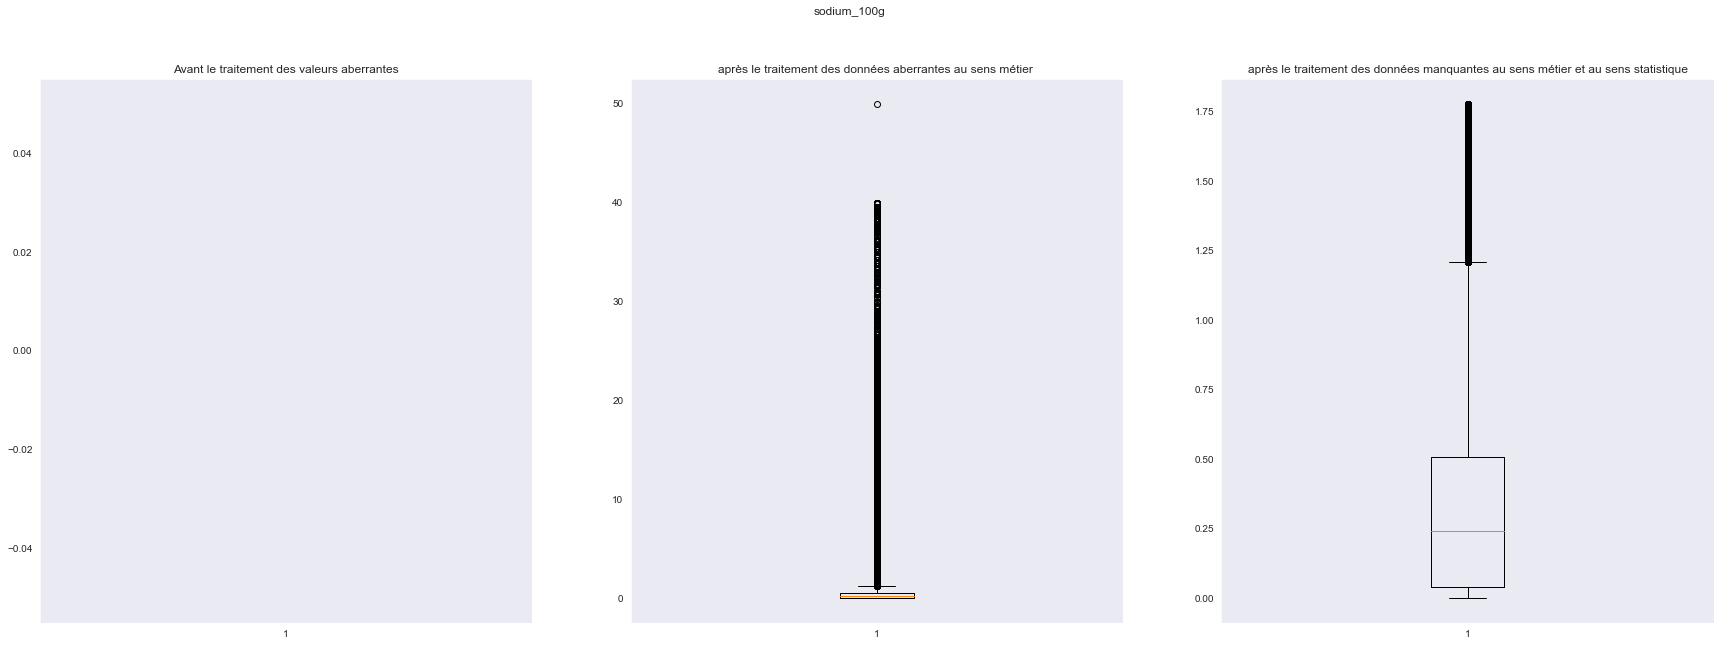

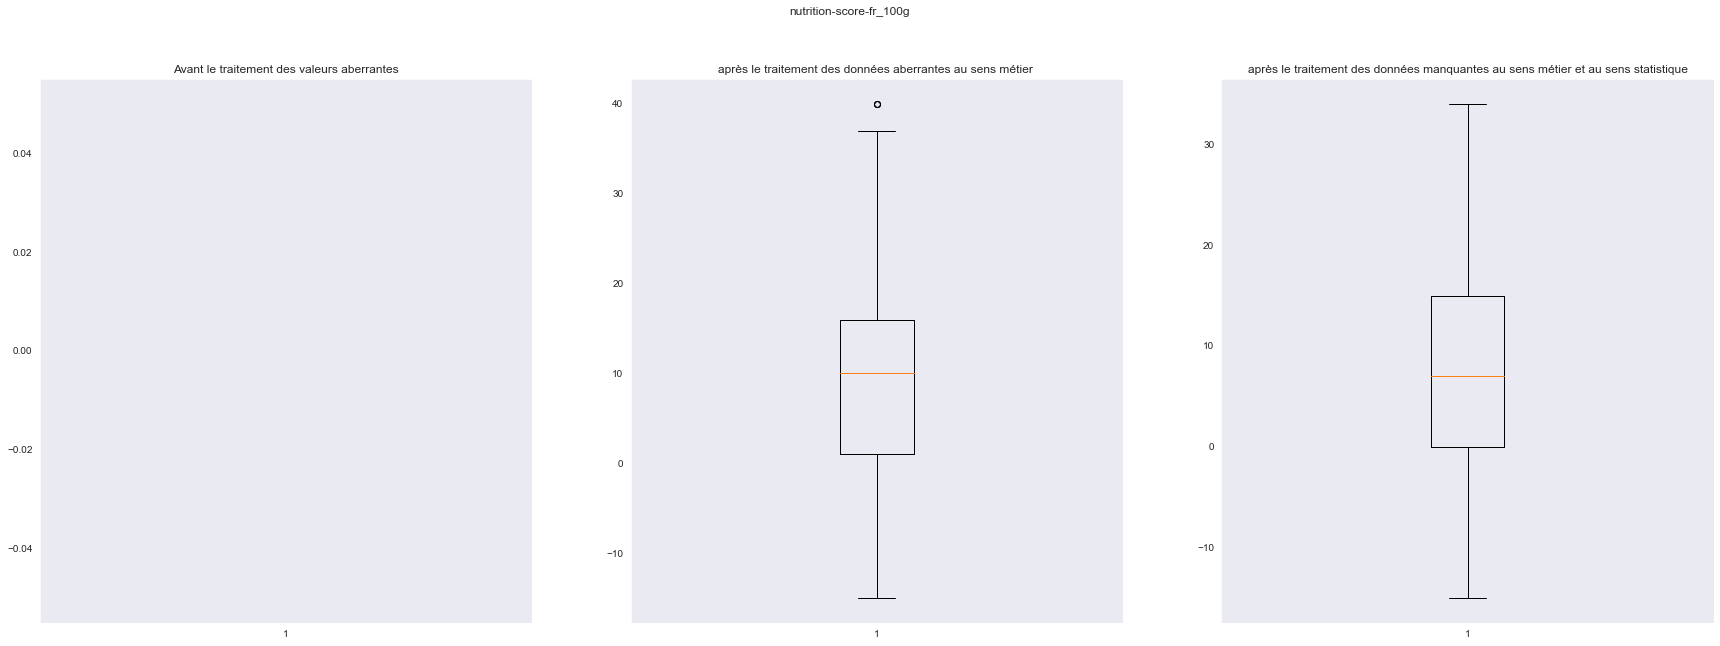

In [18]:
for column in numeric_columns:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))
    fig.suptitle(column)
    ax1.boxplot(df_before_outliers_treatement[column])
    ax1.set_title('Avant le traitement des valeurs aberrantes')
    ax2.boxplot(df_after_first_outliers_treatement[column])
    ax2.set_title('après le traitement des données aberrantes au sens métier ')
    ax3.boxplot(df_after_second_outliers_treatement[column])
    ax3.set_title('après le traitement des données manquantes au sens métier et au sens statistique')

# Visualiser l'évolution du nombre des lignes au cours des traitements 

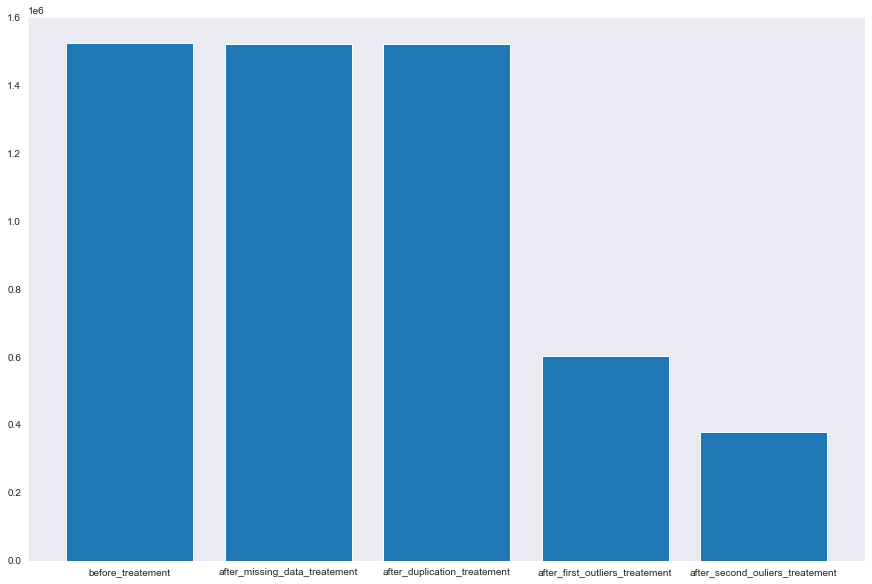

In [19]:
n_rows_evolution = {'before_treatement': df_original.shape[0], 'after_missing_data_treatement': n_rows_missing_data, \
         'after_duplication_treatement': final_n_rows, 'after_first_outliers_treatement': df_after_first_outliers_treatement.shape[0], \
         'after_second_ouliers_treatement': df_after_second_outliers_treatement.shape[0] }
plt.figure(figsize=(15, 10))
values = list(n_rows_evolution.values())
keys = list(n_rows_evolution.keys())
plt.bar(range(len(n_rows_evolution)), values, align='center')
plt.xticks(range(len(n_rows_evolution)), keys)
plt.show()                                                                                                              

# Remplir les valeurs manquantes des colonnes numériques

In [20]:
imputer = KNNImputer(n_neighbors=10000)

df_filled = imputer.fit_transform(df_after_second_outliers_treatement[numeric_columns])

df_after_second_outliers_treatement[numeric_columns] = df_filled

# Eliminer les colonnes dont nous n'avons pas besoin

In [21]:
# Définir une liste de colonnes qui ne nous sont pas utiles pour notre problématique
columns_to_drop = ['code', 'last_modified_datetime', 'countries', 'countries_tags', 'countries_en', 'ingredients_text']
# Rajouter des colonnes qui ne rapportent pas d'informations supplémentaires d'après les boxplots
columns_to_drop += ['ingredients_from_palm_oil_n', 'additives_n', 'ingredients_that_may_be_from_palm_oil_n']
# définir une dataframe finale qui va nous servir dans la suite du traitement
final_df = df_after_second_outliers_treatement.drop(columns_to_drop, axis=1)
# Sauvegarder la dataframe finale que nous allons utiliser dans la suite du traitement
final_df.to_csv(r"C:\Users\RamziAbdelhafidh\Documents\Openclassrooms\Projet 3\data\final_df.csv", index=False)